In [52]:
# PyTorch core components
import torch
import torch.nn as nn
import torch.optim as optim

# Learning rate scheduler
from torch.optim.lr_scheduler import StepLR

# Data utilities
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision

# Logging and visualization
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

# Utility libraries
import numpy as np
import random
import os


In [2]:
class DNN(nn.Module):
    def __init__(self, num_classes):
        super(DNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 512)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(512, 128)
        self.relu = nn.ReLU()
        self.fc4 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

In [3]:
class LightweightCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(LightweightCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # Output: 16 x 28 x 28
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # Output: 16 x 14 x 14

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # Output: 32 x 14 x 14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # Output: 32 x 7 x 7

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # Output: 64 x 7 x 7
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)                      # Output: 64 x 1 x 1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                # Output: 64
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# SE Block
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super(SEBlock, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# Main DWSCNN with wider channels and SE + Dropout + Extra Linear
class DWSCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(DWSCNN, self).__init__()

        def depthwise_separable(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                SEBlock(out_channels)
            )

        self.features = nn.Sequential(
            depthwise_separable(1, 16),     # 16 x 28 x 28
            nn.MaxPool2d(2),                # 16 x 14 x 14

            depthwise_separable(16, 32),    # 32 x 14 x 14
            nn.MaxPool2d(2),                # 32 x 7 x 7

            depthwise_separable(32, 64),    # 64 x 7 x 7
            nn.AdaptiveAvgPool2d(1)         # 64 x 1 x 1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(64, 32, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        # First Convolutional Block
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # Second Convolutional Block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Dropout layer with probability 0.25
        self.dropout = nn.Dropout(p=0.25)

        # Fully Connected Layer
        self.fc1 = nn.Linear(in_features=64*7*7, out_features=128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
def get_transforms(augment=False):
    if augment:
        return transforms.Compose([
            transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    else:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

In [53]:
data_dir = '/home/wins057/Documents/Projects/python-for-dl-homework/week06/data'

# Load the dataset
# Supports MNIST, FashionMNIST, KMNIST, and EMNIST
def load_data(dataset_name, batch_size=64, augment=False, use_mixup=False):
    transform = get_transforms(augment)

    if dataset_name == "MNIST":
        train_set = datasets.MNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.MNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "FashionMNIST":
        train_set = datasets.FashionMNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "KMNIST":
        train_set = datasets.KMNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.KMNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "EMNIST":
        train_set = datasets.EMNIST(root=data_dir, split='balanced', train=True, transform=transform, download=True)
        test_set = datasets.EMNIST(root=data_dir, split='balanced', train=False, transform=transform, download=True)
    else:
        raise ValueError("Unsupported dataset name.")
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [9]:
# Evaluate the model
# Computes accuracy on test set
def evaluate_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [10]:
def log_tensorboard(writer, model, train_loader, dataset_name):
    example_images, _ = next(iter(train_loader))
    writer.add_graph(model, example_images.to(next(model.parameters()).device))
    img_grid = torchvision.utils.make_grid(example_images[:16])
    writer.add_image(f"{dataset_name}_examples", img_grid)

In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [54]:
model = DNN(num_classes=10)
print(f"{count_parameters(model)} parameters in DNN model")
model = DWSCNN(num_classes=10)
print(f"{count_parameters(model)} parameters in DWSCNN model")

731530 parameters in DNN model
8405 parameters in DWSCNN model


In [55]:
# Train the model
# Saves the best model based on validation accuracy
# Logs training metrics to TensorBoard
def train_model(model, train_loader, test_loader, dataset_name="MNIST", epochs=10, lr=0.001, log_dir="runs"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=50, gamma=0.8)

    writer = SummaryWriter(log_dir=os.path.join(log_dir, dataset_name))
    log_tensorboard(writer, model, train_loader, dataset_name)
    model_name = model.__class__.__name__
    checkpoint_dir = os.path.join(f"checkpoints", dataset_name)
    checkpoint_dir = os.path.join(checkpoint_dir, model_name)
    os.makedirs(checkpoint_dir, exist_ok=True)
    saved_model_accs = {}

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

            step = epoch * len(train_loader) + i
            if i % 100 == 99:
                writer.add_scalar("Loss/Train", running_loss / 100, step)
                running_loss = 0.0
            if step % 300 == 0:
                for name, param in model.named_parameters():
                    writer.add_histogram(name, param, step)

        train_acc = correct_train / total_train
        val_acc = evaluate_model(model, test_loader, device)
        scheduler.step()
        writer.add_scalars("Accuracy", {"Train": train_acc, "Validation": val_acc}, epoch)
        print(f"[{dataset_name}] Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
            
        # Save the model every i epochs
        if (epoch + 1) % 10 == 0:
            filename = f"epoch_{epoch+1}.pth"
            save_path = os.path.join(checkpoint_dir, filename)
            torch.save(model.state_dict(), save_path)
            saved_model_accs[filename] = val_acc
            print(f"📦 Saved model to {filename} with accuracy {val_acc:.4f}")
    
    print(f"\n📊 Saved models & Accuracies: \n{saved_model_accs}")
    
    # Select the best model based on validation accuracy
    if saved_model_accs:
        best_filename = max(saved_model_accs, key=lambda k: saved_model_accs[k])
        best_acc = saved_model_accs[best_filename]
        best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
        torch.save(torch.load(os.path.join(checkpoint_dir, best_filename)), best_model_path)
        print(f"\n✅ Saved best model to {best_filename} with accuracy {best_acc:.4f}")
    
        model.load_state_dict(torch.load(best_model_path))
        model = model.to(device)
        model.eval()

    writer.close()
    return model

In [15]:
# Visualize results
# Displays a grid of images with predicted and ground truth labels
# Highlights misclassified examples in red
def visualize_results(model, test_loader, class_names=None, num_images=10):
    model.eval()
    device = next(model.parameters()).device
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    images = images.cpu().numpy()
    predicted = predicted.cpu().numpy()
    labels = labels.cpu().numpy()

    plt.figure(figsize=(num_images * 1.8, 2.5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i][0], cmap='gray')
        plt.axis('off')

        pred = predicted[i]
        gt = labels[i]
        
        if class_names:
            pred_text = class_names[pred]
            gt_text = class_names[gt]
        else:
            pred_text = str(pred)
            gt_text = str(gt)

        # Highlight misclassified examples
        title_color = 'green' if pred == gt else 'red'
        plt.title(f"P:{pred_text}\nGT:{gt_text}", fontsize=8, color=title_color)

    plt.suptitle("Test Predictions vs Ground Truth")
    plt.tight_layout()
    plt.show()

In [16]:
def get_class_names(dataset_name):
    if dataset_name == "FashionMNIST":
        return ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    elif dataset_name == "EMNIST":
        return [
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
            'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
            'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
            'U', 'V', 'W', 'X', 'Y', 'Z',
            'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
        ]

    elif dataset_name == "KMNIST":
        return ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']
        # These correspond to 10 Hiragana characters in the order of the labels
    
    return None  # For MNIST or others


In [ ]:
def visualize_config(model, dataset_name, lr, epochs):
    print("====================================================")
    print(f"Number of parameters: {count_parameters(model)}")
    print(f"Dataset: {dataset_name}")
    print(f"Learning Rate: {lr}")
    print(f"Epochs: {epochs}")
    print("====================================================")
    print("Training...")

In [56]:
def run_training_pipeline(dataset_name="MNIST", epochs=5, lr=0.001, DNN_model=False):
    # Create the model
    num_classes = 47 if dataset_name == "EMNIST" else 10
    if DNN_model:
        # Use DNN model
        model = DNN(num_classes=num_classes)
    else:
        if dataset_name == "EMNIST":
            # Use CNN model for EMNIST
            model = CNN(num_classes=num_classes)
        else:
            # Use Depth-wise CNN model for other datasets
            model = DWSCNN(num_classes=num_classes)

    # Conifgure training
    visualize_config(model, dataset_name, lr, epochs)
    
    # Load dataset
    train_loader, test_loader = load_data(dataset_name, 64, False, False)

    # Train model
    best_model = train_model(model, train_loader, test_loader, dataset_name, epochs=epochs, lr=lr)

    # Visualize results
    class_names = get_class_names(dataset_name)
    visualize_results(best_model, test_loader, class_names=class_names)

### MNIST Training

Number of parameters: 8405
Dataset: MNIST
Learning Rate: 0.0005
Epochs: 150
Training...
[MNIST] Epoch 1: Train Acc=0.5883, Val Acc=0.8132
[MNIST] Epoch 2: Train Acc=0.8110, Val Acc=0.8029
[MNIST] Epoch 3: Train Acc=0.8587, Val Acc=0.9068
[MNIST] Epoch 4: Train Acc=0.8870, Val Acc=0.9262
[MNIST] Epoch 5: Train Acc=0.9050, Val Acc=0.9150
[MNIST] Epoch 6: Train Acc=0.9158, Val Acc=0.9182
[MNIST] Epoch 7: Train Acc=0.9240, Val Acc=0.9151
[MNIST] Epoch 8: Train Acc=0.9320, Val Acc=0.9216
[MNIST] Epoch 9: Train Acc=0.9357, Val Acc=0.9188
[MNIST] Epoch 10: Train Acc=0.9422, Val Acc=0.9456
📦 Saved model to epoch_10.pth with accuracy 0.9456
[MNIST] Epoch 11: Train Acc=0.9461, Val Acc=0.9555
[MNIST] Epoch 12: Train Acc=0.9495, Val Acc=0.9539
[MNIST] Epoch 13: Train Acc=0.9529, Val Acc=0.9548
[MNIST] Epoch 14: Train Acc=0.9556, Val Acc=0.9428
[MNIST] Epoch 15: Train Acc=0.9576, Val Acc=0.9465
[MNIST] Epoch 16: Train Acc=0.9583, Val Acc=0.9227
[MNIST] Epoch 17: Train Acc=0.9616, Val Acc=0.9674
[MN

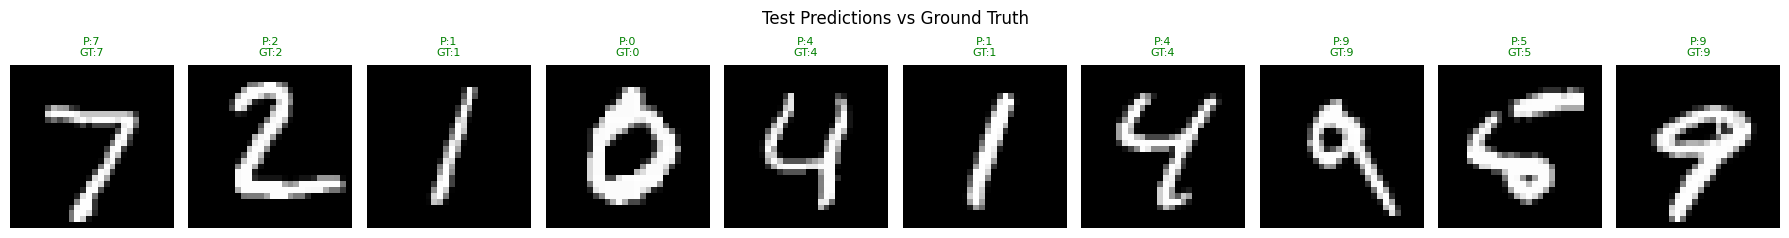

In [ ]:
# Must have Accuracy ~98.06% - 98.55%
run_training_pipeline(dataset_name="MNIST", epochs=150, lr=0.0005, DNN_model=False)

In [51]:
%reload_ext tensorboard

In [43]:
!kill 427586
%load_ext tensorboard
%tensorboard --logdir=runs

/bin/bash: line 1: kill: (427586) - No such process
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


### KMNIST

Number of parameters: 8405
Dataset: KMNIST
Learning Rate: 0.0005
Epochs: 150
Training...
[KMNIST] Epoch 1: Train Acc=0.4802, Val Acc=0.5377
[KMNIST] Epoch 2: Train Acc=0.7171, Val Acc=0.6255
[KMNIST] Epoch 3: Train Acc=0.7760, Val Acc=0.6801
[KMNIST] Epoch 4: Train Acc=0.8104, Val Acc=0.7027
[KMNIST] Epoch 5: Train Acc=0.8323, Val Acc=0.7438
[KMNIST] Epoch 6: Train Acc=0.8462, Val Acc=0.7404
[KMNIST] Epoch 7: Train Acc=0.8606, Val Acc=0.7588
[KMNIST] Epoch 8: Train Acc=0.8681, Val Acc=0.7271
[KMNIST] Epoch 9: Train Acc=0.8782, Val Acc=0.7727
[KMNIST] Epoch 10: Train Acc=0.8860, Val Acc=0.7760
📦 Saved model to epoch_10.pth with accuracy 0.7760
[KMNIST] Epoch 11: Train Acc=0.8913, Val Acc=0.7938
[KMNIST] Epoch 12: Train Acc=0.8979, Val Acc=0.7965
[KMNIST] Epoch 13: Train Acc=0.9044, Val Acc=0.8082
[KMNIST] Epoch 14: Train Acc=0.9072, Val Acc=0.7975
[KMNIST] Epoch 15: Train Acc=0.9091, Val Acc=0.8124
[KMNIST] Epoch 16: Train Acc=0.9134, Val Acc=0.8301
[KMNIST] Epoch 17: Train Acc=0.9154, 

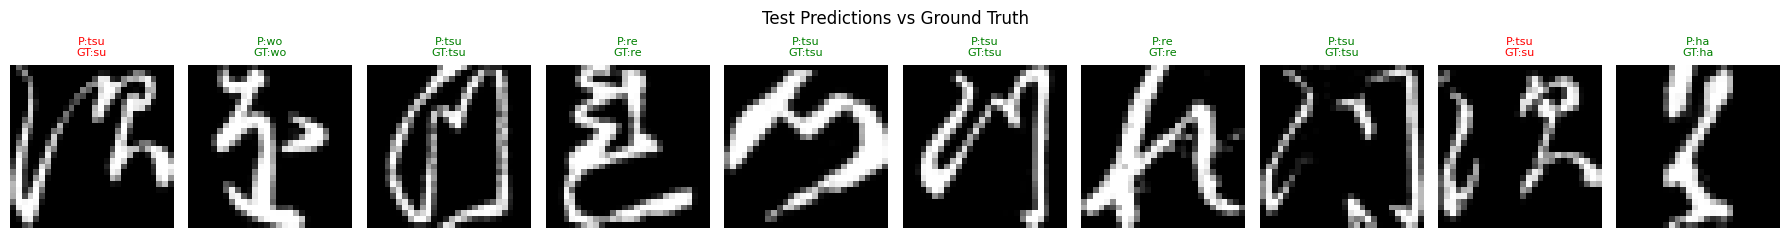

In [ ]:
# Must have Accuracy ~91.09% - 91.33%
run_training_pipeline(dataset_name="KMNIST", epochs=150, lr=0.0005, DNN_model=False)

### Fashion MNIST

Number of parameters: 8405
Dataset: FashionMNIST
Learning Rate: 0.0005
Epochs: 150
Training...
[FashionMNIST] Epoch 1: Train Acc=0.5571, Val Acc=0.7311
[FashionMNIST] Epoch 2: Train Acc=0.7257, Val Acc=0.7652
[FashionMNIST] Epoch 3: Train Acc=0.7586, Val Acc=0.7445
[FashionMNIST] Epoch 4: Train Acc=0.7794, Val Acc=0.8066
[FashionMNIST] Epoch 5: Train Acc=0.7943, Val Acc=0.8139
[FashionMNIST] Epoch 6: Train Acc=0.8059, Val Acc=0.8207
[FashionMNIST] Epoch 7: Train Acc=0.8161, Val Acc=0.8290
[FashionMNIST] Epoch 8: Train Acc=0.8231, Val Acc=0.8289
[FashionMNIST] Epoch 9: Train Acc=0.8299, Val Acc=0.8359
[FashionMNIST] Epoch 10: Train Acc=0.8348, Val Acc=0.8444
📦 Saved model to epoch_10.pth with accuracy 0.8444
[FashionMNIST] Epoch 11: Train Acc=0.8382, Val Acc=0.8489
[FashionMNIST] Epoch 12: Train Acc=0.8434, Val Acc=0.8498
[FashionMNIST] Epoch 13: Train Acc=0.8472, Val Acc=0.8534
[FashionMNIST] Epoch 14: Train Acc=0.8505, Val Acc=0.8565
[FashionMNIST] Epoch 15: Train Acc=0.8529, Val Acc=

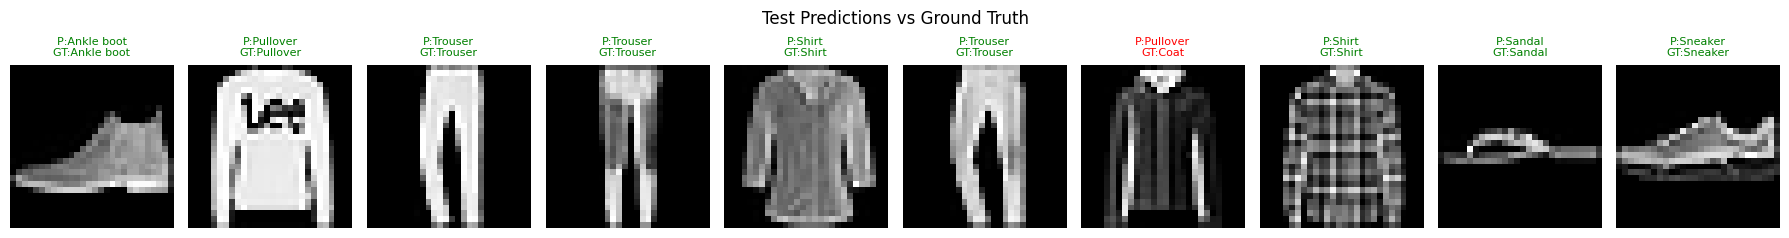

In [ ]:
# Must have Accuracy ~88.69% - 89.03%
run_training_pipeline(dataset_name="FashionMNIST", epochs=150, lr=0.0005, DNN_model=False)

### Tensorboard

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=runs